<a href="https://colab.research.google.com/github/Sofokli5/protein-metrics/blob/main/Enzyme_Metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

print("[STEP 1/5] Installing core structural biology libraries...")
os.system("pip install -q py3Dmol MDAnalysis")

print("[STEP 2/5] Installing FreeSASA for Buried Surface Area (BSA)...")
os.system("pip install -q freesasa")

print("[STEP 3/5] Installing Vina (Python) and OpenBabel (System)...")
os.system("pip install -q vina")
os.system("apt-get update > /dev/null 2>&1")
os.system("apt-get install -y openbabel > /dev/null 2>&1")

print("[STEP 4/5] Installing PRODIGY for interface energy analysis...")
os.system("pip install -q git+https://github.com/haddocking/prodigy.git")

print("[STEP 5/5] Installing Biopython for proximity mapping")
os.system("pip install -q biopython")

print("All dependencies are successfully installed and ready!")

[STEP 1/5] Installing core structural biology libraries...
[STEP 2/5] Installing FreeSASA for Buried Surface Area (BSA)...
[STEP 3/5] Installing Vina (Python) and OpenBabel (System)...
[STEP 4/5] Installing PRODIGY for interface energy analysis...
[STEP 5/5] Installing Biopython for proximity mapping
All dependencies are successfully installed and ready!


In [ ]:
import py3Dmol

print("[STEP 1/3] Defining file paths...")
CIF_PATH = "/content/drive/MyDrive/proteins/terzidis/Holo_CYP17_POR_Rifampicin_model.cif"

print("[STEP 2/3] Loading structural data from CIF file...")
with open(CIF_PATH, 'r') as f:
    cif_data = f.read()

print("[STEP 3/3] Rendering interactive 3D viewer...")
view = py3Dmol.view(width=900, height=600)
view.addModel(cif_data, 'cif')

# Chain A (CYP) in Blue, Chain B (POR) in Green
view.setStyle({'chain': 'A'}, {'cartoon': {'color': 'skyblue'}})
view.setStyle({'chain': 'B'}, {'cartoon': {'color': 'palegreen'}})

# Heteroatoms (Heme and Ligands) in Stick representation
view.addStyle({'hetflag': True}, {'stick': {'colorscheme': 'redCarbon', 'radius': 0.2}})

view.zoomTo()
view.show()

# Create a global dictionary to store metrics
results = {}

[STEP 1/3] Defining file paths...
[STEP 2/3] Loading structural data from CIF file...
[STEP 3/3] Rendering interactive 3D viewer...


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [ ]:
import json
import numpy as np

JSON_PATH = "/content/drive/MyDrive/proteins/terzidis/Holo_CYP17_POR_Rifampicin_confidences.json"

print("Load and parse JSON")
with open(JSON_PATH, 'r') as f:
    data = json.load(f)

print("Calculate Predicted Aligned Error")
pae_matrix = np.array(data['pae'])
average_pae = np.mean(pae_matrix)

print("=========================================")
print(f"Global PAE Score: {average_pae:.2f} Angstroms")
print("(Note: Lower values indicate higher confidence)")
print("=========================================")

results['Global_PAE'] = average_pae

Load and parse JSON
Calculate Predicted Aligned Error
Global PAE Score: 19.70 Angstroms
(Note: Lower values indicate higher confidence)


In [ ]:
import freesasa
import warnings
import os

warnings.filterwarnings("ignore")

print("[STEP 1/5] Defining file paths...")
FILE_PATH = "/content/drive/MyDrive/proteins/terzidis/Holo_CYP17_POR_Rifampicin_model.cif"
PDB_PATH = FILE_PATH.replace(".cif", ".pdb")

print("[STEP 2/5] Cleaning and converting CIF to standard PDB format...")
# Using OpenBabel to strip AlphaFold metadata and create a clean PDB
os.system(f'obabel -icif "{FILE_PATH}" -opdb -O "{PDB_PATH}" > /dev/null 2>&1')

print("[STEP 3/5] Loading structural data into FreeSASA...")
structure = freesasa.Structure(PDB_PATH)
result = freesasa.calc(structure)

print("[STEP 4/5] Calculating surface area for individual chains and the complex...")
sasa_complex = result.totalArea()

# Select Chain A (CYP) and Chain B (POR)
selections = freesasa.selectArea(['chain_A, chain A', 'chain_B, chain B'], structure, result)
sasa_A = selections['chain_A']
sasa_B = selections['chain_B']

print("[STEP 5/5] Computing Buried Surface Area (BSA)...")
# BSA Formula: (Area A + Area B - Area Complex) / 2
bsa = (sasa_A + sasa_B - sasa_complex) / 2

print("\n=========================================")
print("          SURFACE AREA ANALYSIS          ")
print("=========================================")
print(f"SASA Chain A (CYP)     : {sasa_A:.2f} Angstroms^2")
print(f"SASA Chain B (POR)     : {sasa_B:.2f} Angstroms^2")
print(f"Total Complex SASA     : {sasa_complex:.2f} Angstroms^2")
print("-----------------------------------------")
print(f"--> BURIED SURFACE AREA: {bsa:.2f} Angstroms^2")
print("=========================================\n")

results['BSA_Angstrom2'] = bsa
results['SASA_ChainA_Angstrom2'] = sasa_A
results['SASA_ChainB_Angstrom2'] = sasa_B
results['SASA_Complex_Angstrom2'] = sasa_complex

[STEP 1/5] Defining file paths...
[STEP 2/5] Cleaning and converting CIF to standard PDB format...
[STEP 3/5] Loading structural data into FreeSASA...
[STEP 4/5] Calculating surface area for individual chains and the complex...
[STEP 5/5] Computing Buried Surface Area (BSA)...

          SURFACE AREA ANALYSIS          
SASA Chain A (CYP)     : 20505.43 Angstroms^2
SASA Chain B (POR)     : 35007.35 Angstroms^2
Total Complex SASA     : 55665.72 Angstroms^2
-----------------------------------------
--> BURIED SURFACE AREA: -76.47 Angstroms^2



In [ ]:
import MDAnalysis as mda
from MDAnalysis.analysis import distances
import warnings
import os

warnings.filterwarnings("ignore")

print("[STEP 1/4] Defining file path...")
# Make sure to point this to a .pdb file that contains the Heme molecule
FILE_PATH = "/content/drive/MyDrive/proteins/terzidis/Holo_CYP17_POR_Rifampicin_model.cif"
PDB_PATH = FILE_PATH.replace(".cif", ".pdb")

print("[TRIPLE STEP] Cleaning and converting CIF to standard PDB format...")
# Using OpenBabel to strip AlphaFold metadata and create a clean PDB
os.system(f'obabel -icif "{FILE_PATH}" -opdb -O "{PDB_PATH}" > /dev/null 2>&1')

print("[STEP 2/4] Loading structural universe...")
if not os.path.exists(PDB_PATH):
    print("Error: File not found. Please check the path.")
else:
    u = mda.Universe(PDB_PATH)

    print("[STEP 3/4] Locating Heme cofactor and POR chain...")
    # Select all atoms belonging to the Heme molecule
    heme_atoms = u.select_atoms("resname HEM")

    # Select all atoms belonging to Chain B (POR)
    por_atoms = u.select_atoms("segid B or chainID B")

    print("[STEP 4/4] Computing minimum distance matrix...")
    if len(heme_atoms) == 0:
        print("\n[!] WARNING: No Heme (HEM) found in this structure.")
        print("If this is an Apo structure, this result is expected.")
    elif len(por_atoms) == 0:
        print("\n[!] WARNING: POR chain (Chain B) not found.")
    else:
        # Calculate the distance between every Heme atom and every POR atom
        dist_matrix = distances.distance_array(heme_atoms.positions, por_atoms.positions)

        # Find the absolute shortest distance
        min_dist = dist_matrix.min()

        print("\n=========================================")
        print("       ELECTRON TRANSFER ANALYSIS        ")
        print("=========================================")
        print(f"Heme Atoms Detected : {len(heme_atoms)}")
        print(f"POR Atoms Detected  : {len(por_atoms)}")
        print("-----------------------------------------")
        print(f"--> MINIMUM DISTANCE: {min_dist:.2f} Angstroms")
        print("=========================================\n")

        results['Min_Heme_POR_Dist'] = min_dist
        results['Heme_Atoms'] = len(heme_atoms)
        results['POR_Atoms'] = len(por_atoms)

[STEP 1/4] Defining file path...
[TRIPLE STEP] Cleaning and converting CIF to standard PDB format...
[STEP 2/4] Loading structural universe...
[STEP 3/4] Locating Heme cofactor and POR chain...
[STEP 4/4] Computing minimum distance matrix...

       ELECTRON TRANSFER ANALYSIS        
Heme Atoms Detected : 43
POR Atoms Detected  : 5401
-----------------------------------------
--> MINIMUM DISTANCE: 9.16 Angstroms



In [ ]:
import MDAnalysis as mda
from MDAnalysis.analysis import align, rms
import warnings

warnings.filterwarnings("ignore")

print("[STEP 1/4] Defining file paths for Control and Holo models...")
# Paths to your cleaned .pdb files
REF_PATH = "/content/drive/MyDrive/proteins/terzidis/Control_CYP17_POR_Base_model.pdb"
MOBILE_PATH = "/content/drive/MyDrive/proteins/terzidis/Holo_CYP17_POR_Rifampicin_model.pdb"

print("[STEP 2/4] Loading structural universes...")
ref = mda.Universe(REF_PATH)
mobile = mda.Universe(MOBILE_PATH)

print("[STEP 3/4] Superimposing (Aligning) the CYP enzymes (Chain A)...")
# We align the models based strictly on the CYP protein backbone
try:
    align.alignto(mobile, ref, select="chainID A and backbone", match_atoms=False)
except Exception as e:
    print(f"Alignment Error: {e}")

print("[STEP 4/4] Calculating RMSD for POR (Chain B) displacement...")
# Now we measure how much the POR backbone moved due to the ligand
por_mobile = mobile.select_atoms("chainID B and backbone")
por_ref = ref.select_atoms("chainID B and backbone")

if len(por_mobile) == len(por_ref) and len(por_mobile) > 0:
    displacement_rmsd = rms.rmsd(por_mobile.positions, por_ref.positions)
    print("\n=========================================")
    print("          STRUCTURAL DEFORMATION         ")
    print("=========================================")
    print(f"POR Backbone Displacement (RMSD): {displacement_rmsd:.2f} Angstroms")
    print("=========================================\n")
else:
    print("Error: Chain B atom counts do not match or chain not found.")

results['POR_Displacement_RMSD'] = displacement_rmsd

[STEP 1/4] Defining file paths for Control and Holo models...
[STEP 2/4] Loading structural universes...
[STEP 3/4] Superimposing (Aligning) the CYP enzymes (Chain A)...
[STEP 4/4] Calculating RMSD for POR (Chain B) displacement...

          STRUCTURAL DEFORMATION         
POR Backbone Displacement (RMSD): 12.14 Angstroms



In [ ]:
import MDAnalysis as mda
import warnings

warnings.filterwarnings("ignore")

print("[STEP 1/3] Setting file path...")
FILE_PATH = "/content/drive/MyDrive/proteins/terzidis/Holo_CYP17_POR_Rifampicin_model.pdb"

print("[STEP 2/3] Loading structure...")
u = mda.Universe(FILE_PATH)

print("[STEP 3/3] Scanning for contacts under 4.0 Angstroms...")
# Locate the drug by excluding the main protein and the Heme cofactor
drug_atoms = u.select_atoms("not protein and not resname HEM")

if len(drug_atoms) == 0:
    print("[!] ERROR: Could not locate the drug molecule in the structure.")
else:
    # Find all protein residues within 4 Angstroms of the drug
    contact_residues = u.select_atoms("protein and around 4.0 group drug", drug=drug_atoms).residues

    print("\n=========================================")
    print("          CONTACT AMINO ACIDS            ")
    print("=========================================")
    print(f"Total amino acids touching the drug: {len(contact_residues)}")
    print("-----------------------------------------")
    for res in contact_residues:
        print(f" * Residue: {res.resname} {res.resid}")
    print("=========================================\n")

[STEP 1/3] Setting file path...
[STEP 2/3] Loading structure...
[STEP 3/3] Scanning for contacts under 4.0 Angstroms...

          CONTACT AMINO ACIDS            
Total amino acids touching the drug: 20
-----------------------------------------
 * Residue: LEU 43
 * Residue: PRO 44
 * Residue: ARG 45
 * Residue: GLY 47
 * Residue: HIS 48
 * Residue: MET 49
 * Residue: PHE 53
 * Residue: MET 68
 * Residue: THR 73
 * Residue: MET 99
 * Residue: THR 101
 * Residue: LEU 209
 * Residue: SER 210
 * Residue: ASP 212
 * Residue: ASP 216
 * Residue: LEU 217
 * Residue: MET 369
 * Residue: GLU 391
 * Residue: ILE 393
 * Residue: PRO 480



In [ ]:
import MDAnalysis as mda
from vina import Vina
import os
import warnings

warnings.filterwarnings("ignore")

print("[STEP 1/5] Extracting receptor and ligand from complex...")
COMPLEX_PDB = "/content/drive/MyDrive/proteins/terzidis/Holo_CYP17_POR_Rifampicin_model.pdb"

u = mda.Universe(COMPLEX_PDB)
receptor = u.select_atoms("protein")
ligand = u.select_atoms("not protein and not resname HEM")

receptor.write("receptor.pdb")
ligand.write("ligand.pdb")

print("[STEP 2/5] Converting formats to PDBQT using OpenBabel...")
os.system("obabel receptor.pdb -O receptor.pdbqt -xr > /dev/null 2>&1")
os.system("obabel ligand.pdb -O ligand.pdbqt > /dev/null 2>&1")

print("[STEP 3/5] Calculating ligand binding box center...")
centroid = ligand.atoms.center_of_mass().tolist()
print(f"--> Box Center found at: X={centroid[0]:.2f}, Y={centroid[1]:.2f}, Z={centroid[2]:.2f}")

print("[STEP 4/5] Initializing AutoDock Vina scoring engine...")
v = Vina(sf_name='vina', cpu=1)
v.set_receptor('receptor.pdbqt')
v.set_ligand_from_file('ligand.pdbqt')
v.compute_vina_maps(center=centroid, box_size=[30, 30, 30])

print("[STEP 5/5] Computing Free Energy of Binding (Score-Only)...")
energy = v.score()

print("\n=========================================")
print("          THERMODYNAMIC ANALYSIS         ")
print("=========================================")
print(f"--> BINDING FREE ENERGY (Delta G): {energy[0]:.2f} kcal/mol")
print("=========================================\n")

results['Binding_Free_Energy'] = energy[0]

[STEP 1/5] Extracting receptor and ligand from complex...
[STEP 2/5] Converting formats to PDBQT using OpenBabel...
[STEP 3/5] Calculating ligand binding box center...
--> Box Center found at: X=-16.36, Y=-31.35, Z=-3.23
[STEP 4/5] Initializing AutoDock Vina scoring engine...
[STEP 5/5] Computing Free Energy of Binding (Score-Only)...

          THERMODYNAMIC ANALYSIS         
--> BINDING FREE ENERGY (Delta G): 3.78 kcal/mol



In [ ]:
import subprocess
import os
import warnings
import MDAnalysis as mda
import pandas as pd
import io

warnings.filterwarnings("ignore")

print("[STEP 1/3] Defining file paths for Apo structure...")
PDB_PATH = "/content/drive/MyDrive/proteins/terzidis/Holo_CYP17_POR_Rifampicin_model.pdb"
CLEAN_PRODIGY_PATH = "protein_only_apo.pdb"

# Preparing the file
try:
    u = mda.Universe(PDB_PATH)
    protein_only = u.select_atoms("protein")
    protein_only.write(CLEAN_PRODIGY_PATH)
except Exception as e:
    print(f"Error during file preparation: {e}")

print("[STEP 2/3] Running PRODIGY in background...")
output = subprocess.getoutput(f"prodigy {CLEAN_PRODIGY_PATH} --selection A B")

print("[STEP 3/3] Converting text report directly into a clean table...")

# We read the text output line by line and build a table
lines = []
for line in output.split('\n'):
    if ":" in line:
        # Split by the colon to separate the metric name from the value
        parts = line.split(":")
        metric_name = parts[0].strip()
        metric_value = parts[1].strip()
        lines.append({"Metric": metric_name, "Value": metric_value})

# Create the final DataFrame
df_prodigy_clean = pd.DataFrame(lines)

print("\n=========================================================")
print("                    PRODIGY RESULTS TABLE                ")
print("=========================================================")
display(df_prodigy_clean)
print("=========================================================\n")

[STEP 1/3] Defining file paths for Apo structure...
[STEP 2/3] Running PRODIGY in background...
[STEP 3/3] Converting text report directly into a clean table...

                    PRODIGY RESULTS TABLE                


,Metric,Value
0,[+] No. of intermolecular contacts,176
1,[+] No. of Charged-Charged contacts,21.0
2,[+] No. of Charged-Polar contacts,43.0
3,[+] No. of Charged-Apolar contacts,45.0
4,[+] No. of Polar-Polar contacts,12.0
5,[+] No. of Apolar-Polar contacts,29.0
6,[+] No. of Apolar-Apolar contacts,26.0
7,[+] Percentage of Apolar NIS residues,37.58
8,[+] Percentage of Charged NIS residues,30.93
9,[++] predicted binding affinity (kcal.mol-1),-15.4


[STEP 1/3] Loading CIF structure...
[STEP 2/3] Extracting alpha carbon coordinates for interface chains...
[STEP 3/3] Computing distance matrix and generating contact map...


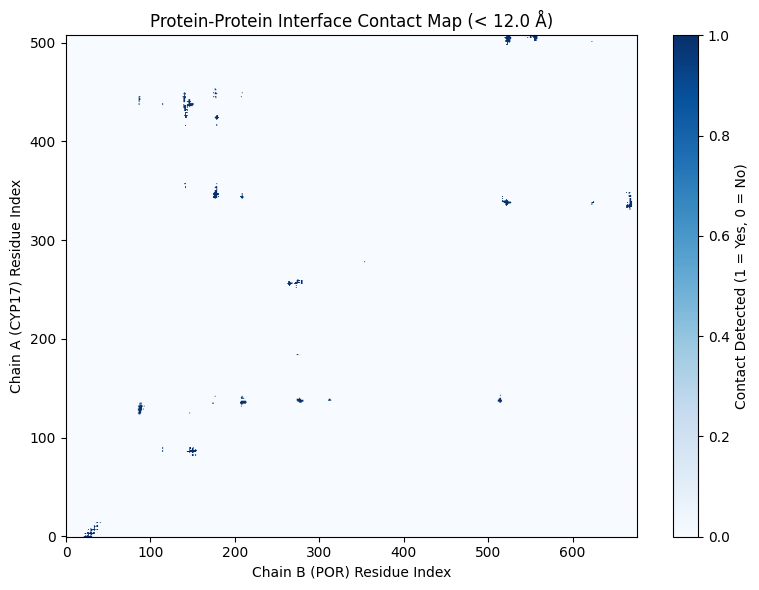

--> Interface contact map generated successfully.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from Bio.PDB.MMCIFParser import MMCIFParser

print("[STEP 1/3] Loading CIF structure...")
parser = MMCIFParser(QUIET=True)
structure = parser.get_structure("complex", "/content/drive/MyDrive/proteins/terzidis/Control_CYP17_POR_Base_model.cif")
model = structure[0]

print("[STEP 2/3] Extracting alpha carbon coordinates for interface chains...")
atoms_A = [atom for atom in model['A'].get_atoms() if atom.get_name() == 'CA']
atoms_B = [atom for atom in model['B'].get_atoms() if atom.get_name() == 'CA']

coords_A = np.array([atom.get_coord() for atom in atoms_A])
coords_B = np.array([atom.get_coord() for atom in atoms_B])

print("[STEP 3/3] Computing distance matrix and generating contact map...")
# Calculate distances between all pairs of residues between Chain A and Chain B
distances = np.linalg.norm(coords_A[:, np.newaxis, :] - coords_B[np.newaxis, :, :], axis=-1)

# Define contact threshold (e.g., 12 Angstroms)
contact_threshold = 12.0
contact_matrix = distances < contact_threshold

# Plotting the interactive-ready static matrix
plt.figure(figsize=(8, 6))
plt.imshow(contact_matrix, cmap="Blues", origin="lower", aspect="auto")
plt.xlabel("Chain B (POR) Residue Index")
plt.ylabel("Chain A (CYP17) Residue Index")
plt.title(f"Protein-Protein Interface Contact Map (< {contact_threshold} Å)")
plt.colorbar(label="Contact Detected (1 = Yes, 0 = No)")
plt.tight_layout()
plt.show()

print("--> Interface contact map generated successfully.")

In [ ]:
import pandas as pd

print("[STEP 1/3] Pivoting PRODIGY table from vertical to horizontal...")

# Transpose the PRODIGY dataframe so metrics become columns
df_prodigy_flipped = df_prodigy_clean.set_index('Metric').T
df_prodigy_flipped.reset_index(drop=True, inplace=True)

print("[STEP 2/3] Merging all structural metrics with PRODIGY data...")

# Set the name for the current complex
complex_name = "CYP17_POR_Rifampicin"

# Create the first table with global metrics (from your previous cells)
df_global = pd.DataFrame([results])
df_global.insert(0, 'Complex_ID', complex_name)

# Combine both tables horizontally (side-by-side)
df_final_all = pd.concat([df_global, df_prodigy_flipped], axis=1)

print("[STEP 3/3] Merge complete! Displaying the ultimate master table:")

# Display the final combined table with absolutely everything
display(df_final_all)

# Optional: Save it to a CSV file in your Drive so you don't lose it
# df_final_all.to_csv(f"/content/drive/MyDrive/proteins/terzidis/{complex_name}_all_metrics.csv", index=False)

[STEP 1/3] Pivoting PRODIGY table from vertical to horizontal...
[STEP 2/3] Merging all structural metrics with PRODIGY data...
[STEP 3/3] Merge complete! Displaying the ultimate master table:


,Complex_ID,Global_PAE,BSA_Angstrom2,SASA_ChainA_Angstrom2,SASA_ChainB_Angstrom2,SASA_Complex_Angstrom2,Min_Heme_POR_Dist,Heme_Atoms,POR_Atoms,POR_Displacement_RMSD,...,[+] No. of Charged-Charged contacts,[+] No. of Charged-Polar contacts,[+] No. of Charged-Apolar contacts,[+] No. of Polar-Polar contacts,[+] No. of Apolar-Polar contacts,[+] No. of Apolar-Apolar contacts,[+] Percentage of Apolar NIS residues,[+] Percentage of Charged NIS residues,[++] predicted binding affinity (kcal.mol-1),[++] predicted dissociation constant (M) at 25.0˚C
0,CYP17_POR_Rifampicin,19.704077,-76.47015,20505.431097,35007.351379,55665.722776,9.157899,43,5401,12.136203,...,21.0,43.0,45.0,12.0,29.0,26.0,37.58,30.93,-15.4,5.4e-12
